<a href="https://colab.research.google.com/github/ThayseBachmeyer/ProcessamentoSinaisI/blob/main/aula1408.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:

import numpy as np
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt





In [ ]:
def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    """
    Calculates the amplitude spectrum of a signal.

    Args:
        signal (np.ndarray): The time-domain signal.
        sampling_frequency (float): The sampling frequency of the signal (Hz).
        single_sided (bool): If True, returns the single-sided spectrum (positive frequencies).
                             If False, returns the full spectrum (positive and negative frequencies).

    Returns:
        tuple: A tuple containing:
            - frequencies (np.ndarray): Array of frequencies (Hz).
            - amplitudes (np.ndarray): Array of corresponding amplitude magnitudes.
    """
    N = len(signal) # Number of sample points
    T = 1.0 / sampling_frequency # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes

In [ ]:
sampling_frequency = 44100 # Hz
duration = 5 # seconds
t = np.linspace(0.0, duration, int(sampling_frequency * duration), endpoint=False)

frequency1 = 500 # Hz
frequency2 = 5000 # Hz


signal = 0.7 * np.cos(2 * np.pi * frequency1 * t) + \
         1.0 * np.cos(2 * np.pi * frequency2 * t) + \
         0.3 * np.random.randn(len(t)) # Add some noise

In [ ]:
sampling_frequency = 44100 # Hz
duration = 5 # seconds
t = np.linspace(0.0, duration, int(sampling_frequency * duration), endpoint=False)

frequency1 = 500 # Hz
frequency2 = 5000 # Hz
frequency3 = 10000

signal = 0.7 * np.cos(2 * np.pi * frequency1 * t) + \
         1.0 * np.cos(2 * np.pi * frequency2 * t) + \
         0.5 * np.cos(2 * np.pi * frequency3 * t )+ \
         0.3 * np.random.randn(len(t)) # Add some noise

In [ ]:

frequencies_single_sided, amplitudes_single_sided = calculate_spectrum(signal, sampling_frequency, single_sided=True)
frequencies_full, amplitudes_full = calculate_spectrum(signal, sampling_frequency, single_sided=False)

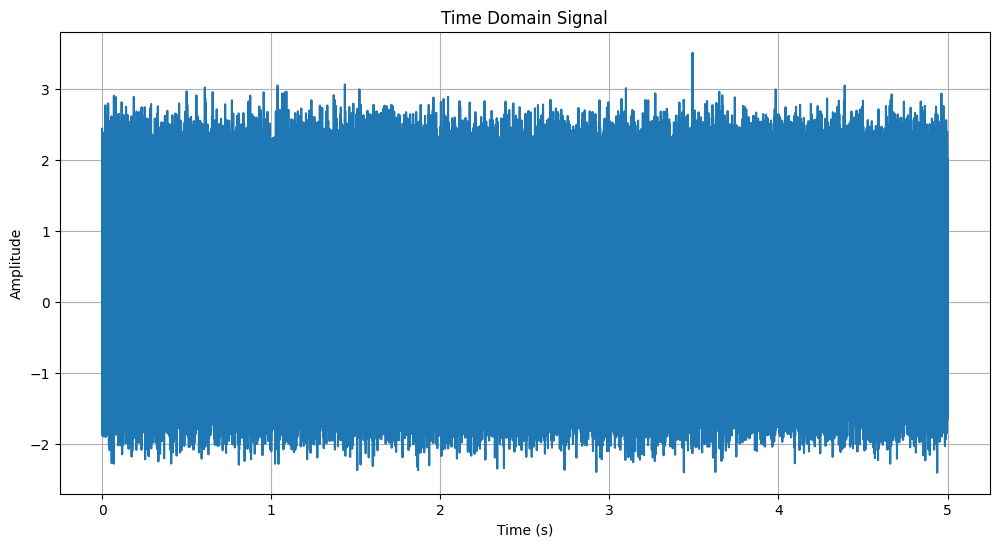

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(t, signal)
plt.title('Time Domain Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

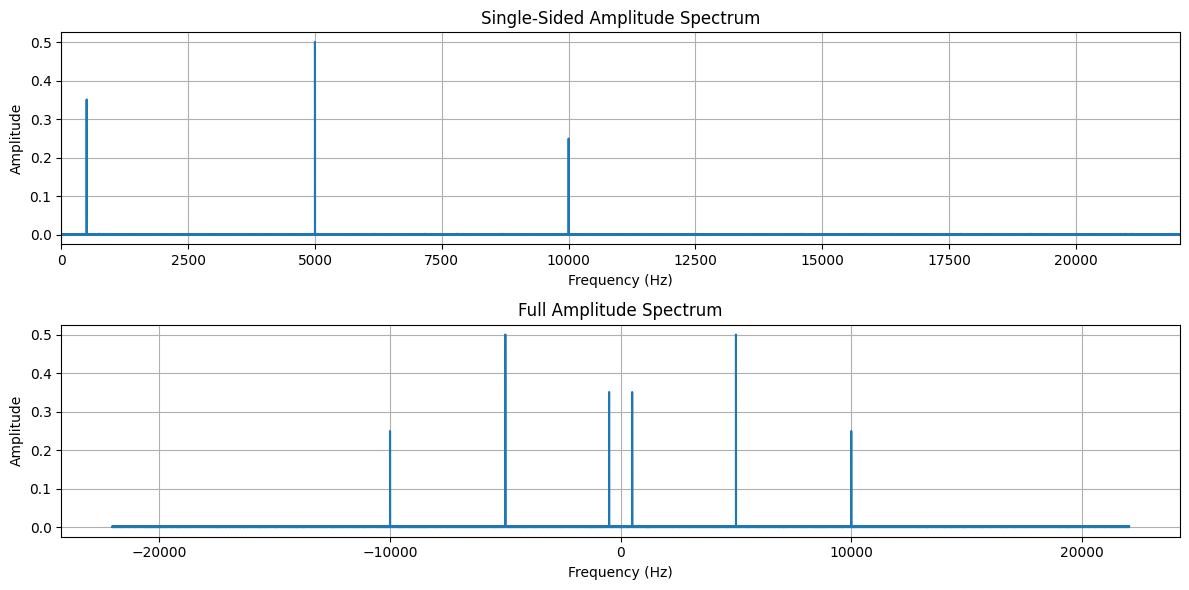

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(frequencies_single_sided, amplitudes_single_sided)
plt.title('Single-Sided Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, sampling_frequency / 2) # Show frequencies up to Nyquist

plt.subplot(2, 1, 2)
plt.plot(frequencies_full, amplitudes_full)
plt.title('Full Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()

### Gráficos de $x(t)$ para Frequências Específicas

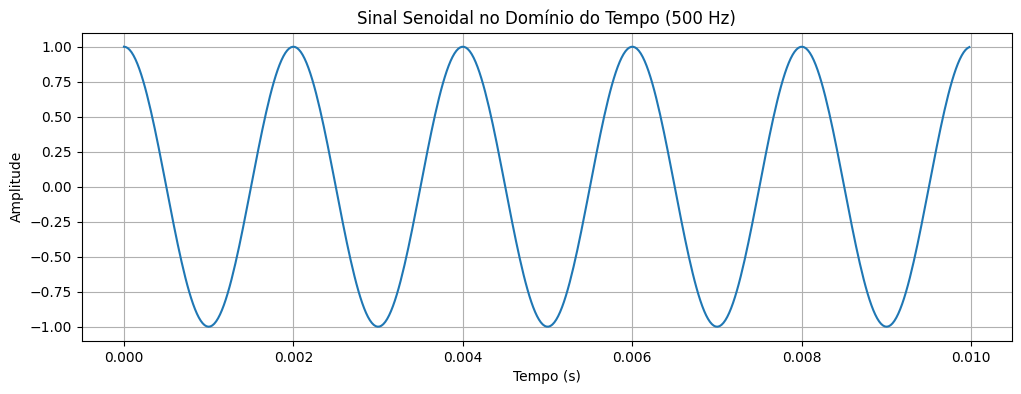

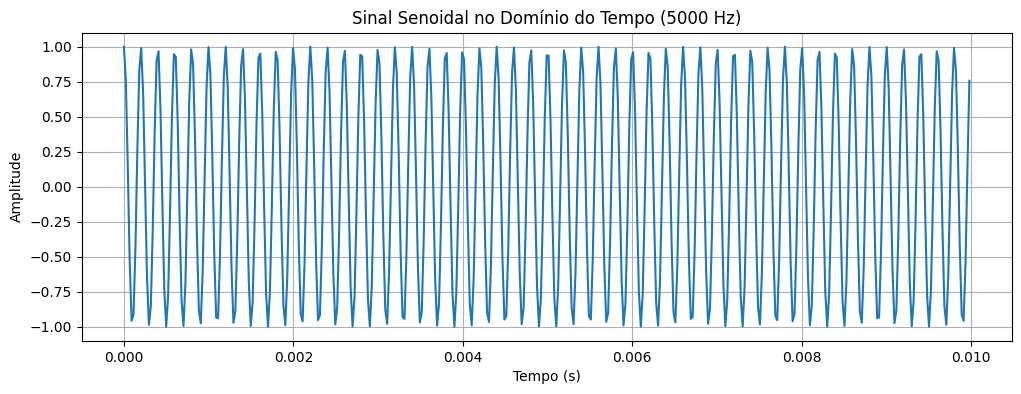

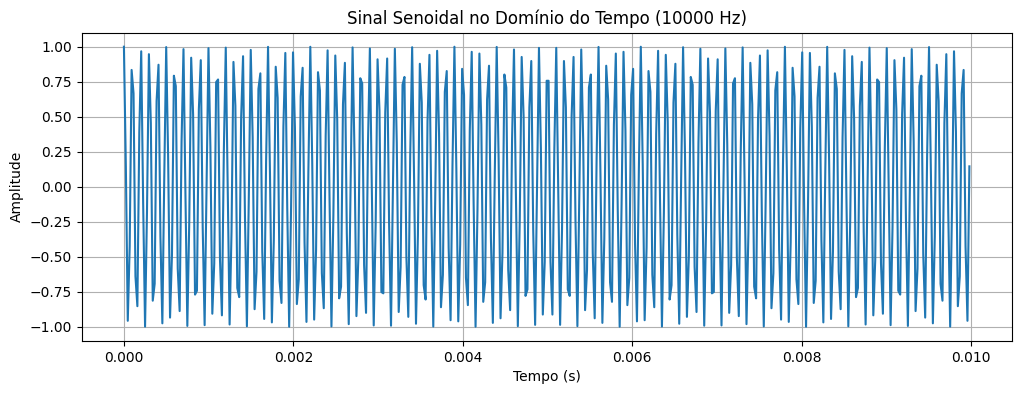

In [ ]:
frequencies_to_plot = [500, 5000, 10000]

sampling_frequency = 44100 # Hz
duration = 0.01 # seconds

# t = np.linspace(0.0, duration, int(sampling_frequency * duration), endpoint=False)
t = np.arange(0,duration,1/sampling_frequency, dtype=float)

for freq in frequencies_to_plot:
    # Generate a cosine signal for the current frequency
    signal_to_plot = 1.0 * np.cos(2 * np.pi * freq * t)

    plt.figure(figsize=(12, 4))
    plt.plot(t, signal_to_plot)
    plt.title(f'Sinal Senoidal no Domínio do Tempo ({freq} Hz)')
    plt.xlabel('Tempo (s)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.show()


<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

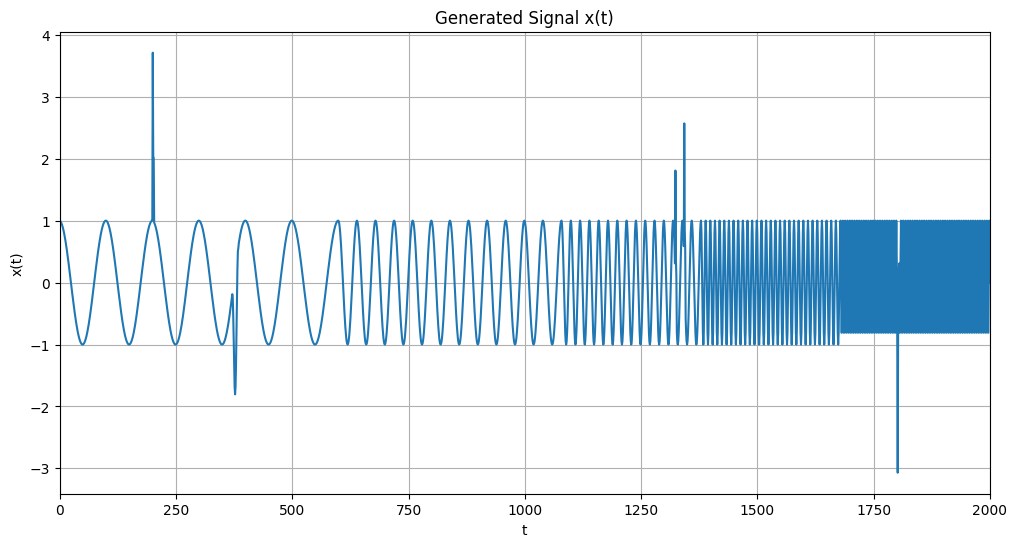

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = 2000                                             # Signal length
t = np.arange(N + 1)                                 # Time values
x = np.zeros_like(t, dtype=np.float64)               # Initialize x as float to allow for sin wave additions

pos_sin = np.array([0, 600, 1080, 1380, 1680, 2000]) # Initial position for each sinusoid function
T_sin = np.array([100, 40, 20, 10, 5])               # Sampling period of each sinusoid function

for i in range(5):
    m = pos_sin[i]
    n = pos_sin[i+1]

    segment_length = n - m
    t_segment_values = np.arange(1, segment_length + 1)

    x[m:n] = np.cos(2*np.pi*t_segment_values/T_sin[i])

amp_imp = np.array([3, -2, 2, 2.5, -2.5])
pos_imp = np.array([200, 372, 1324, 1343, 1802])
T_imp = np.array([5, 25, 5, 5, 5])

for i in range(5):
    m = pos_imp[i]
    relative_end_offset = int(T_imp[i] / 2)
    n = pos_imp[i] + relative_end_offset

    segment_length = n - m + 1
    t_segment_values = np.arange(1, segment_length + 1)

    x[m:n+1] += amp_imp[i] * (np.sin(2 *np.pi*t_segment_values/T_imp[i]))**2

    plt.figure(figsize=(12, 6))
plt.plot(t, x)
plt.title('Generated Signal x(t)')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.xlim(0, N)
plt.grid(True)
plt.show()
